In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
from torch_snippets import Report
import numpy as np
from torch.nn import functional as F
from torch.utils.data import Dataset, DataLoader
from torch.utils.data.sampler import WeightedRandomSampler
import seaborn as sns
import matplotlib as plt
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
np.random.seed(42)


In [2]:
piece_lookup = {
    0 : "K",
    1 : "Q",
    2 : "R",
    3 : "B",
    4 : "N",
    5 : "P",
    6 : "k",
    7 : "q",
    8 : "r",
    9 : "b",
    10 : "n",
    11 : "p",
    6 : "1",
}

value_lookup = {
    "K" : 0,
    "Q" : 1,
    "R" : 2,
    "B" : 3,
    "N" : 4,
    "P" : 5,
    "k" : 6,
    "q" : 7,
    "r" : 8,
    "b" : 9,
    "n" : 10,
    "p" : 11,
}

def y_to_fens(results):
    fens = []

    for i in range(results.shape[0]):
        fen = ''
        empty = 0

        for j in range(64):
            if np.argmax(results[i, j, :]) == 12:
                empty += 1
            else:
                if empty != 0:
                    fen += str(empty)
                    empty = 0
                piece_idx = np.argmax(results[i, j, :])
                fen += piece_lookup[piece_idx]

            if (j+1) % 8 == 0 and j < 63:
                if empty != 0:
                    fen += str(empty)
                    empty = 0
                fen += '/'

        fens.append(fen)
    
    return fens

def fens_to_y(fens):
    results = np.zeros((len(fens), 64, 13))

    for i, fen in enumerate(fens):

        fen = fen.split()[0]
        
        rows = fen.split('/')
        col = 0
        for j, row in enumerate(rows):  
            for char in row:
                if char.isdigit():
                    aux = col + int(char)
                    results[i, col:aux, 12] = 1
                    col = aux
                else:
                    piece_idx = value_lookup[char]
                    results[i, col, piece_idx] = 1
                    col += 1

    return results

In [3]:
class PieceImageClassifier(nn.Module):
    def __init__(self):
        super(PieceImageClassifier, self).__init__()

        self.model = models.mobilenet_v2(weights="MobileNet_V2_Weights.DEFAULT")

        self.model.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), 
            nn.Flatten(),
            nn.Linear(1280, 512),
            nn.ReLU(),
            nn.Linear(512, 12)
        )

    def forward(self, x):
        aux = self.model.features(x)
        outputs = self.model.classifier(aux)
        return outputs

class GamesDataset(Dataset):
    def __init__(self, images, fen):
        self.x = images
        self.y = torch.from_numpy(fen).type(torch.FloatTensor)
        self.n_samples = images.shape[0]
    
    def __getitem__(self, index):
        return (self.x[index], self.y[index])

    def __len__(self):
        return self.n_samples

In [ ]:
imagens_array = torch.load("../Datasets/Images/processed_images/imagens_casa_tensor20000.pt")
fens = np.load("../Datasets/Images/processed_images/pecas_casa_tensor20000.npy")
for i in range(40000, 80001, 20000):
    imagens_array_load = torch.load(f"../Datasets/Images/processed_images/imagens_casa_tensor{i}.pt")
    fens_load = np.load(f"../Datasets/Images/processed_images/pecas_casa_tensor{i}.npy")

    imagens_array = torch.cat((imagens_array, imagens_array_load), dim=0)
    fens = np.concatenate((fens, fens_load), axis=0)


print(imagens_array.size())
print(fens.shape)

torch.Size([80000, 3, 224, 224])
(80000, 12)


In [8]:
class_frequencies = np.sum(fens[:int(len(fens)*.80)], axis=0)

class_frequencies = torch.from_numpy(class_frequencies).float()
weights = 1.0 / (class_frequencies + 1e-6)
weights = weights / weights.sum()

print("Class frequencies:", class_frequencies)
print("Class weights:", weights)

datasetTrain = GamesDataset(imagens_array[:int(len(imagens_array)*.80)], fens[:int(len(fens)*.80)])

sample_weights = np.zeros(len(datasetTrain))
for idx, (_, fen) in enumerate(datasetTrain):
    class_idx = fen.nonzero()[0].item()
    sample_weights[idx] = weights[class_idx]

sample_weights = torch.from_numpy(sample_weights)

sampler = WeightedRandomSampler(weights=sample_weights, num_samples=40000, replacement=True)

dataLoaderTrain = DataLoader(dataset=datasetTrain, batch_size=32, sampler=sampler)

datasetTest = GamesDataset(imagens_array[int(len(imagens_array)*.80):], fens[int(len(fens)*.80):])
dataLoaderTest = DataLoader(dataset=datasetTest, batch_size=32)

print(f"Train: {len(dataLoaderTrain.dataset)}")
print(f"Test: {len(dataLoaderTest.dataset)}")

Class frequencies: tensor([15702.,  3475.,  3712.,  4529.,  2221.,  2357., 15619.,  3460.,  3867.,
         4459.,  2243.,  2356.])
Class weights: tensor([0.0186, 0.0841, 0.0787, 0.0645, 0.1316, 0.1240, 0.0187, 0.0844, 0.0756,
        0.0655, 0.1303, 0.1240])
Train: 64000
Test: 16000


In [9]:
model = PieceImageClassifier()
model.to(device)


criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-6, weight_decay=1e-4)
lr_scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.7)

In [ ]:
num_epochs = 20
log = Report(num_epochs)


for epoch in range(num_epochs):

    model.train()        
    N = len(dataLoaderTrain)
    for bx, data in enumerate(dataLoaderTrain):
        total = 0
        right = 0

        pos, fen_y = data

        pos = pos.to(device)
        fen_y = fen_y.to(device)

        fen_pred = model(pos)

        loss = criterion(fen_pred, fen_y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        fen_pred = fen_pred.cpu().detach().numpy().astype('float32')
        fen_y = fen_y.cpu().detach().numpy().astype('float32')

        for i in range(len(fen_pred)):
            total += 1            
            if np.argmax(fen_pred[i, :]) == np.argmax(fen_y[i, :]):
                right += 1

    
        accuracy_train = right/total * 100

        log.record((epoch+(bx+1)/N), trn_loss=loss, trn_acc=accuracy_train, end='\r')



    model.eval()
    with torch.no_grad():                
        N = len(dataLoaderTest)
        for bx, data in enumerate(dataLoaderTest):
            total = 0
            right = 0

            pos, fen_y = data

            pos = pos.to(device)
            fen_y = fen_y.to(device)

            fen_pred = model(pos)

            loss_test = criterion(fen_pred, fen_y)

            fen_pred = fen_pred.cpu().detach().numpy().astype('float32')
            fen_y = fen_y.cpu().detach().numpy().astype('float32')

            for i in range(len(fen_pred)):
                total += 1                
                if np.argmax(fen_pred[i, :]) == np.argmax(fen_y[i, :]):
                    right += 1

            accuracy_test = right/total * 100


            log.record((epoch+(bx+1)/N), val_loss=loss, val_acc=accuracy_test, end='\r')
    
    if (epoch+1)%2==0: log.report_avgs(epoch+1)
    lr_scheduler.step()


torch.save(model.state_dict(), '../Models/imageClassifier.pth')


EPOCH: 2.000  trn_acc: 86.965  trn_loss: 1.575  val_loss: 1.073  val_acc: 86.619  (286.54s - 2578.89s remaining)
EPOCH: 4.000  trn_acc: 89.448  trn_loss: 0.677  val_loss: 0.654  val_acc: 87.188  (574.83s - 2299.33s remaining)
EPOCH: 6.000  trn_acc: 90.920  trn_loss: 0.424  val_loss: 0.517  val_acc: 90.594  (859.03s - 2004.39s remaining)
EPOCH: 8.000  trn_acc: 92.405  trn_loss: 0.329  val_loss: 0.481  val_acc: 90.800  (1151.71s - 1727.57s remaining)
EPOCH: 10.000  trn_acc: 93.510  trn_loss: 0.279  val_loss: 0.311  val_acc: 91.256  (1434.98s - 1434.98s remaining)
EPOCH: 12.000  trn_acc: 93.985  trn_loss: 0.252  val_loss: 0.315  val_acc: 91.250  (1717.12s - 1144.74s remaining)
EPOCH: 14.000  trn_acc: 94.172  trn_loss: 0.239  val_loss: 0.339  val_acc: 91.131  (1998.34s - 856.43s remaining)
EPOCH: 16.000  trn_acc: 94.052  trn_loss: 0.233  val_loss: 0.076  val_acc: 91.175  (2295.78s - 573.95s remaining)
EPOCH: 18.000  trn_acc: 94.147  trn_loss: 0.228  val_loss: 0.238  val_acc: 90.994  (2582.

100%|██████████| 121/121 [00:00<00:00, 162.27it/s]


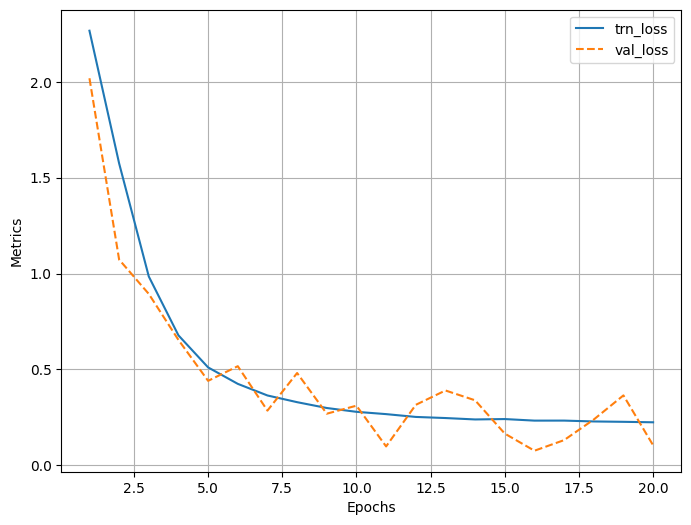

100%|██████████| 121/121 [00:00<00:00, 172.21it/s]


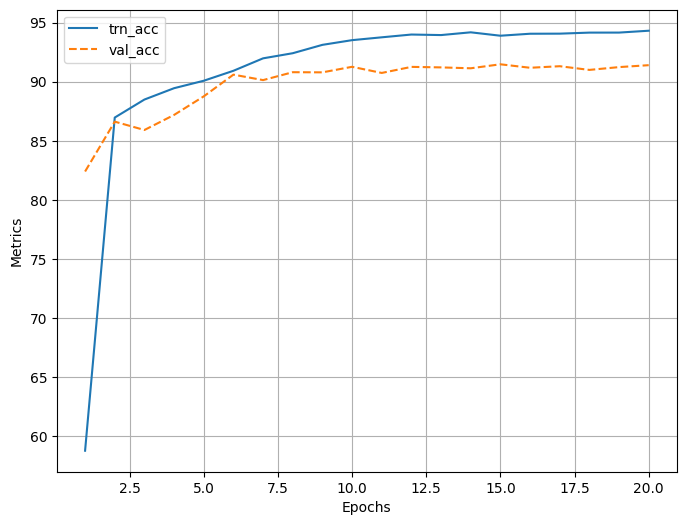

In [11]:
log.plot_epochs(['trn_loss','val_loss'])
log.plot_epochs(['trn_acc','val_acc'])

# Test and Confusion Matrix

In [ ]:
model = PieceImageClassifier()
model.to(device)
model.load_state_dict(torch.load("..\Models/imageClassifier.pth"))
model.eval()

PieceImageClassifier(
  (model): MobileNetV2(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU6(inplace=True)
      )
      (1): InvertedResidual(
        (conv): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): ReLU6(inplace=True)
          )
          (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
      )
      (2): InvertedResidual(
        (conv): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(16, 96, kernel_

Test Accuracy: 91.40%


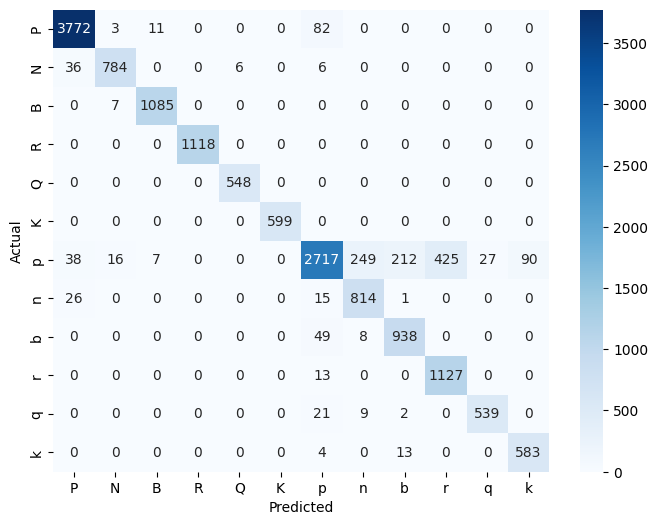

In [ ]:
# Define a mapping between numeric labels and letters
label_mapping = {0: 'P', 1: 'N', 2: 'B', 3: 'R', 4: 'Q', 5: 'K', 6: 'p', 7: 'n', 8: 'b', 9: 'r', 10: 'q', 11: 'k'}

total = 0
right = 0
y_true = []
y_pred = []

with torch.no_grad():                
    N = len(dataLoaderTest)
    for bx, data in enumerate(dataLoaderTest):

        pos, fen_y = data

        pos = pos.to(device)
        fen_y = fen_y.to(device)

        fen_pred = model(pos)

        fen_pred = fen_pred.cpu().detach().numpy().argmax(axis=1)
        fen_y = fen_y.cpu().detach().numpy().argmax(axis=1)

        y_true.extend(fen_y)
        y_pred.extend(fen_pred)

        total += len(fen_y)                
        right += np.sum(fen_pred == fen_y)

accuracy_test = right/total * 100

print(f"Test Accuracy: {accuracy_test:.2f}%")

# Calculate confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Convert numeric labels to letters
label_names = [label_mapping[i] for i in range(len(label_mapping))]

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_names, yticklabels=label_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()
